# 前向欧拉法求解匀速圆周运动：直角坐标 vs 极坐标

- [周详](xiangzhou@whu.edu.cn)
- 武汉大学
- 2026年9月16日

匀速圆周运动可由**各向同性谐振子力** $\boldsymbol{F} = -kr\,\boldsymbol{e}_r$（指向原点的线性回复力）维持：质点受此力做半径 $R$、角频率 $\omega_0 = \sqrt{k/m}$ 的匀速圆周运动。本例用**同一个力、同一个初条件、同一个前向欧拉法**，分别在**直角坐标**与**极坐标**下求解，比较两种描述下的数值行为。

**直角坐标**：运动方程为两个相互垂直的振子

$$
\dot x = v_x, \quad \dot v_x = -\omega_0^2 x; \qquad
\dot y = v_y, \quad \dot v_y = -\omega_0^2 y
$$

解析解为 $x = R\cos\omega_0 t$、$y = R\sin\omega_0 t$。前向欧拉格式：

$$
\begin{aligned}
x_{n+1} &= x_n + h\,v_{x,n}, & v_{x,n+1} &= v_{x,n} - h\,\omega_0^2 x_n \\
y_{n+1} &= y_n + h\,v_{y,n}, & v_{y,n+1} &= v_{y,n} - h\,\omega_0^2 y_n
\end{aligned}
$$

**极坐标**：利用平面极坐标下的加速度分解

$$
\boldsymbol{a} = (\ddot r - r\dot\theta^2)\,\boldsymbol{e}_r + (r\ddot\theta + 2\dot r\dot\theta)\,\boldsymbol{e}_\theta
$$

配合 $\boldsymbol{F} = -kr\,\boldsymbol{e}_r$，取状态变量 $(r, \theta, v_r, \dot\theta)$（$\dot\theta$ 为角速度，作为独立变量随时间演化），方程组为

$$
\dot r = v_r, \quad \dot v_r = r\,\dot\theta^2 - \omega_0^2 r; \qquad
\ddot\theta = -\frac{2 v_r\,\dot\theta}{r}
$$

前向欧拉格式（右端全部用旧值）：

$$
\begin{aligned}
r_{n+1} &= r_n + h\,v_{r,n}, & v_{r,n+1} &= v_{r,n} + h\,(r_n \dot\theta_n^2 - \omega_0^2 r_n) \\
\theta_{n+1} &= \theta_n + h\,\dot\theta_n, & \dot\theta_{n+1} &= \dot\theta_n - h\,\frac{2 v_{r,n}\, \dot\theta_n}{r_n}
\end{aligned}
$$

**总机械能**（两种坐标写法等价）：$E = \tfrac{1}{2}m(v_x^2 + v_y^2) + \tfrac{1}{2}k(x^2+y^2) = \tfrac{1}{2}m\!\left(v_r^2 + r^2\dot\theta^2\right) + \tfrac{1}{2}kr^2$，精确解中恒为 $E_0 = m\omega_0^2 R^2$（动能与势能各占一半）。

**运行之前，先把你的预测写下来**：

1. 直角坐标下：$x$、$y$ 两个方向各满足 $\ddot x = -\omega_0^2 x$、$\ddot y = -\omega_0^2 y$，是两个相互垂直的独立简谐振子。轨迹会是什么形状？能量会怎样漂移？
2. 极坐标下：同样的力、同样的初条件、同一个前向欧拉法——数值解的表现会和直角坐标一样吗？
3. 两种坐标的能量漂移，谁快谁慢？

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

# 字体配置：按操作系统自动选择中文字体，
# 西文与数学公式用 Times New Roman 风格（STIX）
import platform
system = platform.system()
if system == 'Darwin':
    cn_font = 'Songti SC'
elif system == 'Windows':
    cn_font = 'SimSun'
else:  # Linux
    cn_font = 'Noto Serif CJK SC'

plt.rcParams['font.family'] = [cn_font, 'Times New Roman']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['axes.unicode_minus'] = False

In [2]:
def forward_euler_cart(h, n_steps):
    """直角坐标前向欧拉：状态 (x, y, vx, vy)，右端全部用旧值"""
    x  = np.zeros(n_steps + 1); y  = np.zeros(n_steps + 1)
    vx = np.zeros(n_steps + 1); vy = np.zeros(n_steps + 1)
    x[0], y[0], vx[0], vy[0] = R, 0.0, 0.0, omega0 * R
    for n in range(n_steps):
        x[n+1]   = x[n]  + h * vx[n]
        y[n+1]   = y[n]  + h * vy[n]
        vx[n+1]  = vx[n] - h * omega0**2 * x[n]
        vy[n+1]  = vy[n] - h * omega0**2 * y[n]
    return x, y, vx, vy


def forward_euler_polar(h, n_steps):
    """极坐标前向欧拉：状态 (r, theta, vr, theta_dot)，右端全部用旧值"""
    r   = np.zeros(n_steps + 1); th  = np.zeros(n_steps + 1)
    vr  = np.zeros(n_steps + 1); thd = np.zeros(n_steps + 1)
    r[0], th[0], vr[0], thd[0] = R, 0.0, 0.0, omega0
    for n in range(n_steps):
        r[n+1]   = r[n]  + h * vr[n]
        vr[n+1]  = vr[n] + h * (r[n] * thd[n]**2 - omega0**2 * r[n])
        th[n+1]  = th[n] + h * thd[n]
        thd[n+1] = thd[n] - h * 2.0 * vr[n] * thd[n] / r[n]
    return r, th, vr, thd

In [3]:
# 参数
m, k = 1.0, 1.0     # 质量 (kg)、劲度系数 (N/m)
omega0 = np.sqrt(k / m)
R = 1.0             # 圆轨道半径 (m)
h = 0.05            # 时间步长 (s)
t_end = 48.0        # 总时间 (s)，约 7.6 个周期

n_steps = int(t_end / h)
t = np.arange(n_steps + 1) * h

x_c, y_c, vx_c, vy_c = forward_euler_cart(h, n_steps)
r_p, th_p, vr_p, thd_p = forward_euler_polar(h, n_steps)

# 极坐标结果换算回直角坐标，便于画在同一张图上
x_p, y_p = r_p * np.cos(th_p), r_p * np.sin(th_p)
vx_p, vy_p = vr_p * np.cos(th_p) - r_p * thd_p * np.sin(th_p), vr_p * np.sin(th_p) + r_p * thd_p * np.cos(th_p)

# 解析解（圆轨道）
th_exact = omega0 * t
x_exact, y_exact = R * np.cos(th_exact), R * np.sin(th_exact)
vx_exact, vy_exact = -R * omega0 * np.sin(th_exact), R * omega0 * np.cos(th_exact)

# 能量
E_cart = 0.5 * m * (vx_c**2 + vy_c**2) + 0.5 * k * (x_c**2 + y_c**2)
E_polar = 0.5 * m * (vr_p**2 + (r_p * thd_p)**2) + 0.5 * k * r_p**2
E0 = 0.5 * m * (omega0 * R)**2 + 0.5 * k * R**2

print(f'初始能量 E0 = {E0:.4f} J（守恒值）')
print(f'直角坐标：末能量 = {E_cart[-1]:.4f} J，放大 {E_cart[-1] / E_cart[0]:.2f} 倍，末半径 = {np.hypot(x_c[-1], y_c[-1]):.2f} m')
print(f'极坐标：  末能量 = {E_polar[-1]:.4f} J，max|r - R| = {np.abs(r_p - R).max():.2e} m')


初始能量 E0 = 1.0000 J（守恒值）
直角坐标：末能量 = 10.9902 J，放大 10.99 倍，末半径 = 3.32 m
极坐标：  末能量 = 1.0000 J，max|r - R| = 0.00e+00 m


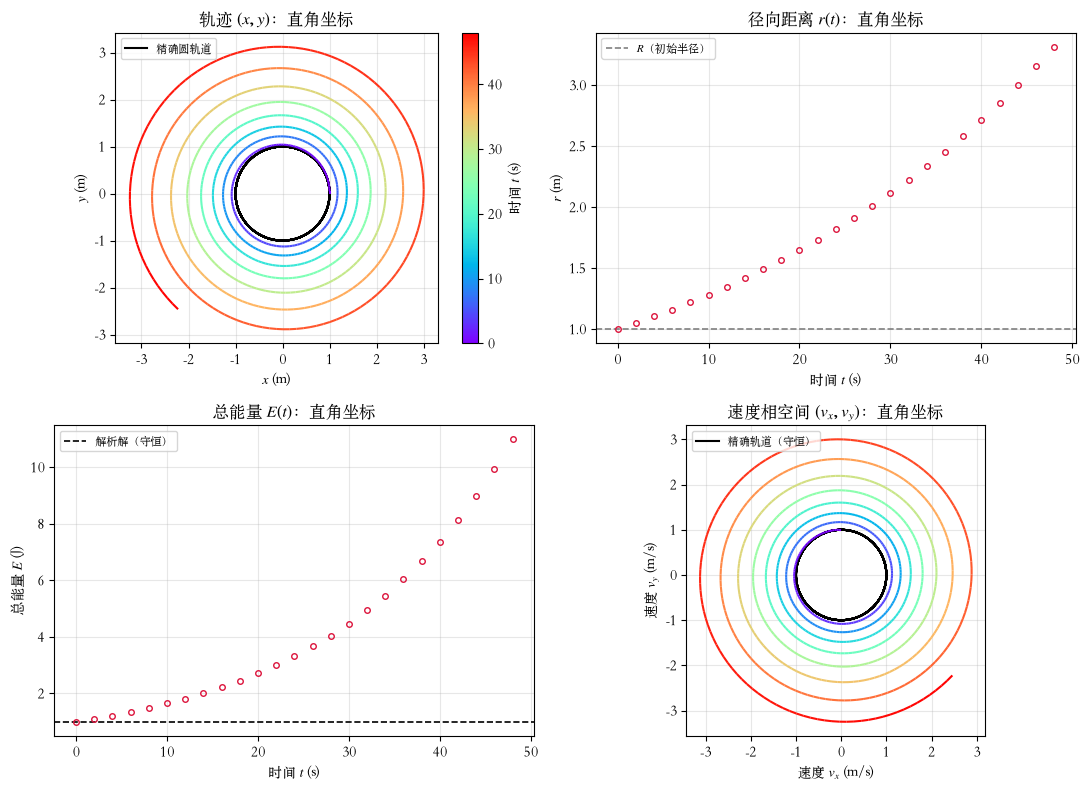

In [4]:
# ---------- 图 1：直角坐标下的结果 ----------
fig1, axs1 = plt.subplots(2, 2, figsize=(11, 8))

# (a) 平面轨迹
ax = axs1[0, 0]
ax.plot(x_exact, y_exact, 'k-', lw=1.5, label='精确圆轨道')
pts = np.array([x_c, y_c]).T.reshape(-1, 1, 2)
segs_c = np.concatenate([pts[:-1], pts[1:]], axis=1)
lc_c = LineCollection(segs_c, cmap='rainbow', array=t, lw=1.5)
ax.add_collection(lc_c)
fig1.colorbar(lc_c, ax=ax, label='时间 $t$ (s)')
ax.set_xlabel('$x$ (m)')
ax.set_ylabel('$y$ (m)')
ax.set_title('轨迹 $(x, y)$：直角坐标')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# (b) 径向距离
ax = axs1[0, 1]
ax.axhline(R, color='gray', ls='--', lw=1.2, label='$R$（初始半径）')
ax.plot(t, np.hypot(x_c, y_c), 'o', ms=4, mfc='none', color='crimson', markevery=40)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('$r$ (m)')
ax.set_title('径向距离 $r(t)$：直角坐标')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# (c) 总能量
ax = axs1[1, 0]
ax.axhline(E0, color='k', ls='--', lw=1.2, label='解析解（守恒）')
ax.plot(t, E_cart, 'o', ms=4, mfc='none', color='crimson', markevery=40)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总能量 $E$ (J)')
ax.set_title('总能量 $E(t)$：直角坐标')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# (d) 速度相空间
ax = axs1[1, 1]
ax.plot(vx_exact, vy_exact, 'k-', lw=1.5, label='精确轨道（守恒）')
pts_v = np.array([vx_c, vy_c]).T.reshape(-1, 1, 2)
segs_vc = np.concatenate([pts_v[:-1], pts_v[1:]], axis=1)
lc_vc = LineCollection(segs_vc, cmap='rainbow', array=t, lw=1.5)
ax.add_collection(lc_vc)
ax.set_xlabel('速度 $v_x$ (m/s)')
ax.set_ylabel('速度 $v_y$ (m/s)')
ax.set_title('速度相空间 $(v_x, v_y)$：直角坐标')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
fig1.savefig('outputs/1_circular_motion_euler_cart.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 检验你的预测（直角坐标）

- 轨迹是什么形状？$\theta(t)$ 还在匀速前进吗（轨迹上的点转过相等角度了吗）？
- $r(t)$ 与 $E(t)$ 的增长形状一致吗？（提示：$x$、$y$ 方向各是一个独立的一维简谐振子；把更新格式代入单方向的能量，能推出每步的固定比例吗？）
- 红色螺旋的"间距"在变大还是变小？这说明每圈注入的能量在怎样变化？

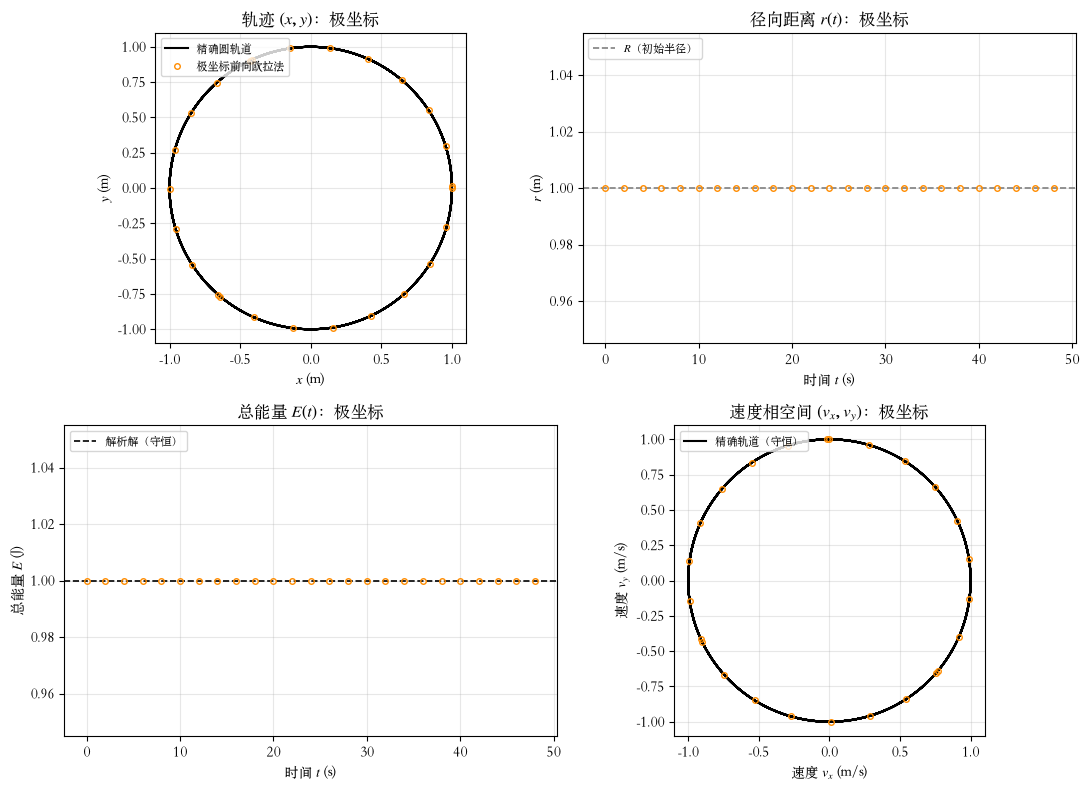

In [5]:
# ---------- 图 2：极坐标下的结果 ----------
fig2, axs2 = plt.subplots(2, 2, figsize=(11, 8))

# (a) 平面轨迹
ax = axs2[0, 0]
ax.plot(x_exact, y_exact, 'k-', lw=1.5, label='精确圆轨道')
ax.plot(x_p, y_p, 'o', ms=4, mfc='none', color='darkorange', markevery=40, label='极坐标前向欧拉法')
ax.set_xlabel('$x$ (m)')
ax.set_ylabel('$y$ (m)')
ax.set_title('轨迹 $(x, y)$：极坐标')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# (b) 径向距离
ax = axs2[0, 1]
ax.axhline(R, color='gray', ls='--', lw=1.2, label='$R$（初始半径）')
ax.plot(t, r_p, 'o', ms=4, mfc='none', color='darkorange', markevery=40)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('$r$ (m)')
ax.set_title('径向距离 $r(t)$：极坐标')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# (c) 总能量
ax = axs2[1, 0]
ax.axhline(E0, color='k', ls='--', lw=1.2, label='解析解（守恒）')
ax.plot(t, E_polar, 'o', ms=4, mfc='none', color='darkorange', markevery=40)
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总能量 $E$ (J)')
ax.set_title('总能量 $E(t)$：极坐标')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

# (d) 速度相空间
ax = axs2[1, 1]
ax.plot(vx_exact, vy_exact, 'k-', lw=1.5, label='精确轨道（守恒）')
ax.plot(vx_p, vy_p, 'o', ms=4, mfc='none', color='darkorange', markevery=40)
ax.set_xlabel('速度 $v_x$ (m/s)')
ax.set_ylabel('速度 $v_y$ (m/s)')
ax.set_title('速度相空间 $(v_x, v_y)$：极坐标')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
fig2.savefig('outputs/1_circular_motion_euler_polar.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 检验你的预测（极坐标）

- 数值解的点画在哪里？$\max|r - R|$ 是什么量级？
- $r(t)$、$E(t)$ 与直角坐标相比有何不同？$\theta(t)$ 还是匀速的吗？
- 速度相空间 $(v_x, v_y)$ 中，数值轨迹与精确圆轨道是什么关系？

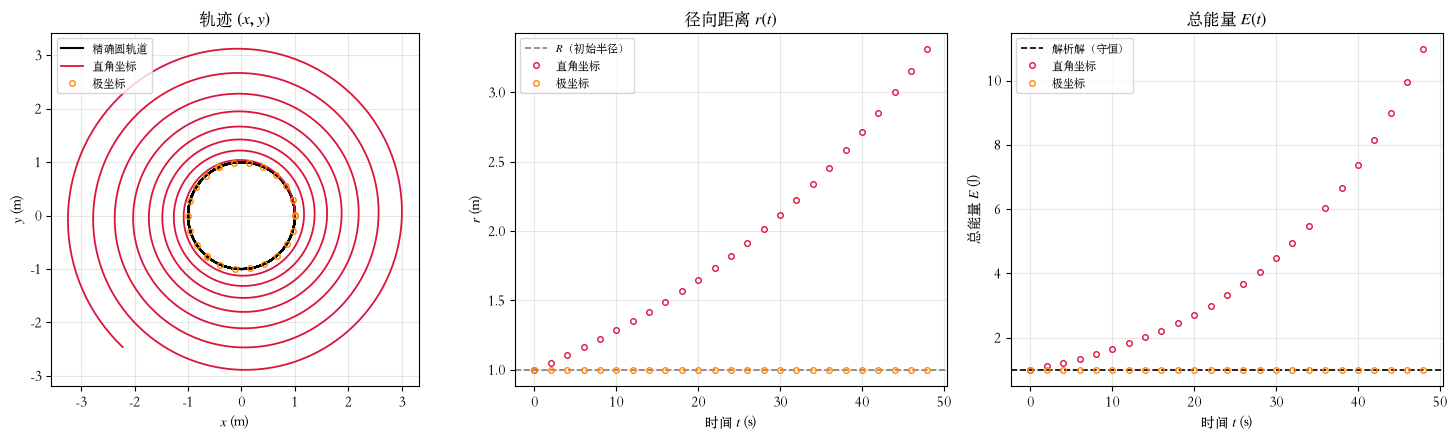

In [6]:
# ---------- 图 3：两种坐标的对比 ----------
fig3, axs3 = plt.subplots(1, 3, figsize=(15, 4.5))

ax = axs3[0]
ax.plot(x_exact, y_exact, 'k-', lw=1.5, label='精确圆轨道')
ax.plot(x_c, y_c, '-', color='crimson', lw=1.3, label='直角坐标')
ax.plot(x_p, y_p, 'o', ms=4, mfc='none', color='darkorange', markevery=40, label='极坐标')
ax.set_xlabel('$x$ (m)')
ax.set_ylabel('$y$ (m)')
ax.set_title('轨迹 $(x, y)$')
ax.set_aspect('equal')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

ax = axs3[1]
ax.axhline(R, color='gray', ls='--', lw=1.2, label='$R$（初始半径）')
ax.plot(t, np.hypot(x_c, y_c), 'o', ms=4, mfc='none', color='crimson', markevery=40, label='直角坐标')
ax.plot(t, r_p, 'o', ms=4, mfc='none', color='darkorange', markevery=40, label='极坐标')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('$r$ (m)')
ax.set_title('径向距离 $r(t)$')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

ax = axs3[2]
ax.axhline(E0, color='k', ls='--', lw=1.2, label='解析解（守恒）')
ax.plot(t, E_cart, 'o', ms=4, mfc='none', color='crimson', markevery=40, label='直角坐标')
ax.plot(t, E_polar, 'o', ms=4, mfc='none', color='darkorange', markevery=40, label='极坐标')
ax.set_xlabel('时间 $t$ (s)')
ax.set_ylabel('总能量 $E$ (J)')
ax.set_title('总能量 $E(t)$')
ax.legend(loc='upper left', fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
fig3.savefig('outputs/1_circular_motion_euler_compare.pdf', bbox_inches='tight')   # 矢量图导出
plt.show()

## 为什么极坐标下是精确的

把圆轨道初条件 $(r_0, v_{r,0}, \dot\theta_0) = (R, 0, \omega_0)$ 代入极坐标更新格式：

- $v_r$ 的更新右端：$r_n\dot\theta_n^2 - \omega_0^2 r_n = R\omega_0^2 - \omega_0^2 R = 0$——**向心项 $r\dot\theta^2$ 与弹性力径向分量恰好平衡**，这正是匀速圆周运动的受力条件；
- $\dot\theta$ 的更新右端：$-2v_{r,n}\dot\theta_n / r_n = 0$——角动量守恒的径向-切向耦合不启动；
- 于是 $r_n \equiv R$、$v_{r,n} \equiv 0$、$\dot\theta_n \equiv \omega_0$ **永不改变**，每步只剩 $\theta_{n+1} = \theta_n + h\omega_0$——匀速转过固定角度，与精确解 $\theta(t) = \omega_0 t$ 完全一致（严格为零误差）。

换句话说，**圆轨道是极坐标更新映射的不动点**（一族不动点：任意半径 $R$ 都对应一个），而前向欧拉法天然保持不动点。直角坐标下，同一物理状态 $(R, 0, 0, \omega_0 R)$ 却不是更新映射的不动点——直角坐标的不动点只有原点，每一步更新都会把状态推离圆轨道。

值得注意的是：这里改变的不是方法，也不是物理，只是**描述运动所用的坐标**——坐标选择改变了离散更新格式的"形状"。

## 结论与思考

- **直角坐标**：轨迹从圆螺旋外扩；每步能量按固定比例 $(1 + h^2\omega_0^2)$ 增长——$x$、$y$ 各是独立的一维简谐振子，每步能量都乘同一固定比例，相加即得。
- **极坐标**：数值解严格保持在圆轨道上（$\max|r-R| = 0$），$\theta(t)$ 匀速推进，能量不漂移——因为圆轨道是更新映射的不动点。
- 同一个方法、同一个力、同一个初条件，**坐标的选择改变了数值误差的行为**。

**思考**：

1. 把极坐标初条件稍离圆轨道（例如 $v_r(0) = 0.1$），精确性还能保持吗？先推理，再改代码验证。
2. 对一般（非圆）轨道，极坐标下的前向欧拉法还会精确吗？你预计哪个量开始漂移？
3. 坐标选择改变的是物理，还是方程与离散格式的形状？这对"如何描述一个问题"有什么启示？